# Advanced Crop Disease Diagnosis

## Characteristics:
- **15+ disease types**
- **2000 samples** with realistic soil profiles
- **Disease-specific parameter ranges** for each condition
- **Weighted k-NN voting** (confidence scores)
- **Multilingual queries** (Hindi templates)
- **95%+ accuracy** with better generalization
- **Similar case retrieval** for explainability

## Step 1: Install Dependencies

In [ ]:
!pip install sentence-transformers scikit-learn pandas numpy google-genai tqdm -q

## 🎯 Step 2: Generate Dataset

In [ ]:
import pandas as pd
import numpy as np
import random
from typing import Dict, List, Tuple

class AdvancedDatasetGenerator:
    """Generate realistic synthetic crop disease data with proper soil profiles"""

    def __init__(self):
        # Disease definitions with realistic symptom variations and soil profiles
        self.diseases = {
            "early_blight": {
                "symptoms": [
                    "brown spots with concentric rings on older leaves",
                    "dark brown lesions on leaves with target pattern",
                    "leaves have brown circular spots",
                    "older leaves turning brown with ring patterns"
                ],
                "solution": "Apply chlorothalonil or mancozeb fungicide. Remove infected leaves. Improve air circulation.",
                "soil_profile": {"N": (40, 80), "P": (30, 60), "K": (40, 70), "temp": (20, 30), "humidity": (60, 90), "ph": (5.5, 7.0)},
                "crops": ["tomato", "potato"]
            },
            "late_blight": {
                "symptoms": [
                    "water-soaked spots on leaves turning brown",
                    "white fungal growth on leaf underside",
                    "rapidly spreading brown lesions on leaves and stems"
                ],
                "solution": "Apply metalaxyl or copper fungicide immediately. Remove infected plants. Avoid overhead irrigation.",
                "soil_profile": {"N": (50, 90), "P": (25, 55), "K": (35, 65), "temp": (15, 25), "humidity": (75, 95), "ph": (5.5, 6.8)},
                "crops": ["potato", "tomato"]
            },
            "bacterial_wilt": {
                "symptoms": [
                    "plants wilting during day recovering at night",
                    "sudden wilting of entire plant",
                    "stems oozing white bacterial slime when cut"
                ],
                "solution": "Remove and destroy infected plants. Rotate crops. Use resistant varieties. Improve drainage.",
                "soil_profile": {"N": (60, 85), "P": (35, 65), "K": (45, 75), "temp": (25, 35), "humidity": (70, 90), "ph": (6.0, 7.5)},
                "crops": ["tomato", "potato", "chili", "banana"]
            },
            "powdery_mildew": {
                "symptoms": [
                    "white powdery coating on leaves",
                    "leaves covered with white dusty powder",
                    "white fungal patches on upper leaf surface"
                ],
                "solution": "Spray sulfur fungicide or potassium bicarbonate. Improve air circulation.",
                "soil_profile": {"N": (45, 75), "P": (30, 60), "K": (40, 70), "temp": (20, 30), "humidity": (50, 70), "ph": (6.0, 7.5)},
                "crops": ["wheat", "mango", "groundnut", "chili"]
            },
            "nitrogen_deficiency": {
                "symptoms": [
                    "older leaves turning yellow from tip",
                    "pale yellow-green coloration on lower leaves",
                    "stunted growth with yellowish leaves"
                ],
                "solution": "Apply urea or ammonium sulfate. Use NPK 20-10-10 fertilizer. Add organic compost.",
                "soil_profile": {"N": (20, 45), "P": (30, 60), "K": (40, 70), "temp": (20, 35), "humidity": (40, 80), "ph": (5.5, 7.5)},
                "crops": ["rice", "maize", "wheat", "tomato", "cotton"]
            },
            "phosphorus_deficiency": {
                "symptoms": [
                    "leaves turning dark green with purple tint",
                    "slow growth with purple-colored leaves",
                    "older leaves developing purple coloration"
                ],
                "solution": "Apply single super phosphate or DAP fertilizer. Use bone meal or rock phosphate.",
                "soil_profile": {"N": (50, 80), "P": (10, 30), "K": (40, 70), "temp": (18, 32), "humidity": (45, 75), "ph": (5.0, 6.5)},
                "crops": ["maize", "wheat", "rice", "potato"]
            },
            "potassium_deficiency": {
                "symptoms": [
                    "leaf margins turning yellow then brown",
                    "scorching of leaf edges",
                    "yellow and brown tips on older leaves"
                ],
                "solution": "Apply muriate of potash or potassium sulfate. Use wood ash or kelp meal.",
                "soil_profile": {"N": (60, 85), "P": (35, 65), "K": (15, 35), "temp": (22, 35), "humidity": (45, 75), "ph": (5.5, 7.5)},
                "crops": ["tomato", "potato", "banana", "cotton"]
            },
            "iron_deficiency": {
                "symptoms": [
                    "young leaves turning yellow with green veins",
                    "interveinal chlorosis on new growth",
                    "newest leaves yellow but veins remain green"
                ],
                "solution": "Spray ferrous sulfate solution. Apply iron chelate. Lower soil pH if alkaline.",
                "soil_profile": {"N": (55, 80), "P": (35, 65), "K": (40, 70), "temp": (20, 32), "humidity": (50, 80), "ph": (7.0, 8.5)},
                "crops": ["rice", "groundnut", "mango", "chili"]
            },
            "aphid_infestation": {
                "symptoms": [
                    "tiny insects clustering on new growth",
                    "leaves curling with small green bugs",
                    "sticky honeydew on leaves with ants"
                ],
                "solution": "Spray neem oil or insecticidal soap. Use imidacloprid. Introduce ladybugs.",
                "soil_profile": {"N": (50, 85), "P": (30, 60), "K": (35, 65), "temp": (22, 32), "humidity": (55, 85), "ph": (6.0, 7.5)},
                "crops": ["cotton", "chili", "potato", "wheat"]
            },
            "whitefly_attack": {
                "symptoms": [
                    "tiny white flying insects under leaves",
                    "yellowing leaves with white flies",
                    "sooty mold on leaves with white insects"
                ],
                "solution": "Use yellow sticky traps. Spray neem oil or spiromesifen. Apply thiamethoxam.",
                "soil_profile": {"N": (55, 85), "P": (30, 60), "K": (40, 70), "temp": (24, 35), "humidity": (60, 90), "ph": (6.0, 7.5)},
                "crops": ["tomato", "cotton", "chili", "potato"]
            },
            "leaf_curl_virus": {
                "symptoms": [
                    "leaves curling upward or downward",
                    "distorted twisted leaves",
                    "leaves rolling and becoming thick"
                ],
                "solution": "Remove infected plants. Control whiteflies and aphids. Use resistant varieties.",
                "soil_profile": {"N": (55, 80), "P": (30, 60), "K": (40, 70), "temp": (25, 35), "humidity": (60, 85), "ph": (6.0, 7.5)},
                "crops": ["tomato", "chili", "cotton"]
            },
            "blast_disease": {
                "symptoms": [
                    "diamond-shaped lesions on leaves",
                    "brown spots with gray centers on leaves",
                    "neck rot causing panicles to break"
                ],
                "solution": "Apply tricyclazole or azoxystrobin. Use resistant varieties. Avoid excessive nitrogen.",
                "soil_profile": {"N": (70, 95), "P": (25, 55), "K": (35, 65), "temp": (20, 30), "humidity": (75, 95), "ph": (5.5, 7.0)},
                "crops": ["rice", "wheat"]
            },
            "root_rot": {
                "symptoms": [
                    "plants wilting with brown rotting roots",
                    "stunted growth with mushy roots",
                    "yellowing plant with blackened root system"
                ],
                "solution": "Improve drainage. Apply Trichoderma. Use carbendazim drench. Avoid overwatering.",
                "soil_profile": {"N": (50, 80), "P": (30, 60), "K": (40, 70), "temp": (22, 32), "humidity": (75, 95), "ph": (5.5, 7.0)},
                "crops": ["tomato", "chili", "potato", "groundnut"]
            },
            "fruit_borer": {
                "symptoms": [
                    "holes in fruits with caterpillars inside",
                    "damaged fruits with entry holes",
                    "fruits dropping prematurely with bore holes"
                ],
                "solution": "Use pheromone traps. Spray spinosad or Bt. Remove infected fruits.",
                "soil_profile": {"N": (60, 85), "P": (35, 65), "K": (45, 75), "temp": (23, 33), "humidity": (60, 85), "ph": (6.0, 7.5)},
                "crops": ["tomato", "chili", "cotton"]
            },
            "anthracnose": {
                "symptoms": [
                    "dark sunken lesions on fruits",
                    "black spots on ripe fruits",
                    "circular brown spots on leaves and fruits"
                ],
                "solution": "Apply copper fungicide or mancozeb. Remove infected fruits. Improve air circulation.",
                "soil_profile": {"N": (55, 80), "P": (30, 60), "K": (40, 70), "temp": (22, 32), "humidity": (70, 95), "ph": (5.5, 7.0)},
                "crops": ["mango", "chili", "tomato", "banana"]
            }
        }

        # Hindi query templates for multilingual support
        self.hindi_templates = [
            "mere {crop} ke {symptom}",
            "{crop} mein {symptom} dikh rahe hain",
            "{crop} ki fasal ko {symptom} ki samasya hai"
        ]

    def generate_dataset(self, n_samples: int = 2000) -> pd.DataFrame:
        """Generate enhanced synthetic dataset with realistic patterns"""
        rows = []

        for _ in range(n_samples):
            # Select disease and compatible crop
            disease_name, disease_info = random.choice(list(self.diseases.items()))
            crop = random.choice(disease_info["crops"])
            symptom = random.choice(disease_info["symptoms"])

            # Generate query (20% Hindi, 80% English)
            if random.random() < 0.2:
                hindi_symptom = self._translate_simple(symptom)
                query = random.choice(self.hindi_templates).format(
                    crop=crop, symptom=hindi_symptom
                )
            else:
                query_formats = [
                    f"My {crop} {symptom}",
                    f"My {crop} plants have {symptom}",
                    f"I see {symptom} on my {crop}",
                    f"{crop} showing {symptom}"
                ]
                query = random.choice(query_formats)

            # Generate realistic soil parameters based on disease profile
            profile = disease_info["soil_profile"]
            N = np.random.uniform(*profile["N"])
            P = np.random.uniform(*profile["P"])
            K = np.random.uniform(*profile["K"])
            temp = np.random.uniform(*profile["temp"])
            humidity = np.random.uniform(*profile["humidity"])
            ph = np.random.uniform(*profile["ph"])
            rainfall = np.random.uniform(50, 250)

            # Add 30% outliers for robustness
            if random.random() < 0.3:
                N += np.random.uniform(-20, 20)
                P += np.random.uniform(-10, 10)
                K += np.random.uniform(-15, 15)

            rows.append([
                query,
                disease_name,
                disease_info["solution"],
                crop,
                round(max(N, 20), 2),
                round(max(P, 10), 2),
                round(max(K, 15), 2),
                round(temp, 2),
                round(humidity, 2),
                round(ph, 2),
                round(rainfall, 2)
            ])

        df = pd.DataFrame(
            rows,
            columns=["query", "label", "solution", "crop", "N", "P", "K",
                    "temperature", "humidity", "ph", "rainfall"]
        )

        return df

    def _translate_simple(self, text: str) -> str:
        """Simple keyword translation for Hindi queries"""
        translations = {
            "yellow": "peele", "brown": "bhure", "white": "safed",
            "spots": "dhabbe", "leaves": "patton", "wilting": "sukh"
        }
        for eng, hindi in translations.items():
            text = text.replace(eng, hindi)
        return text

# Generate dataset
print("Generating enhanced dataset...")
generator = AdvancedDatasetGenerator()
df = generator.generate_dataset(n_samples=2000)

# Save to CSV
df.to_csv("enhanced_crop_disease_dataset.csv", index=False)

print(f"Dataset created with {len(df)} samples")
print(f"Diseases: {df['label'].nunique()}")
print(f"Crops: {df['crop'].nunique()}")
print(f"\nSample data:")
df.head()

Generating enhanced dataset...
Dataset created with 2000 samples
Diseases: 15
Crops: 10

Sample data:


,query,label,solution,crop,N,P,K,temperature,humidity,ph,rainfall
0,I see newest leaves yellow but veins remain gr...,iron_deficiency,Spray ferrous sulfate solution. Apply iron che...,groundnut,64.37,58.74,64.11,26.09,51.23,7.97,199.97
1,I see leaves curling with small green bugs on ...,aphid_infestation,Spray neem oil or insecticidal soap. Use imida...,cotton,83.53,51.80,44.28,26.59,73.84,6.20,136.50
2,rice mein bhure dhabbe with gray centers on pa...,blast_disease,Apply tricyclazole or azoxystrobin. Use resist...,rice,85.10,47.31,56.97,28.84,75.54,5.63,146.38
3,My mango plants have white powdery coating on ...,powdery_mildew,Spray sulfur fungicide or potassium bicarbonat...,mango,52.94,61.70,56.37,29.85,57.93,6.76,169.34
4,cotton ki fasal ko scorching of leaf edges ki ...,potassium_deficiency,Apply muriate of potash or potassium sulfate. ...,cotton,60.50,54.88,23.79,31.30,47.72,6.16,129.41


## Step 3: Analyze Dataset

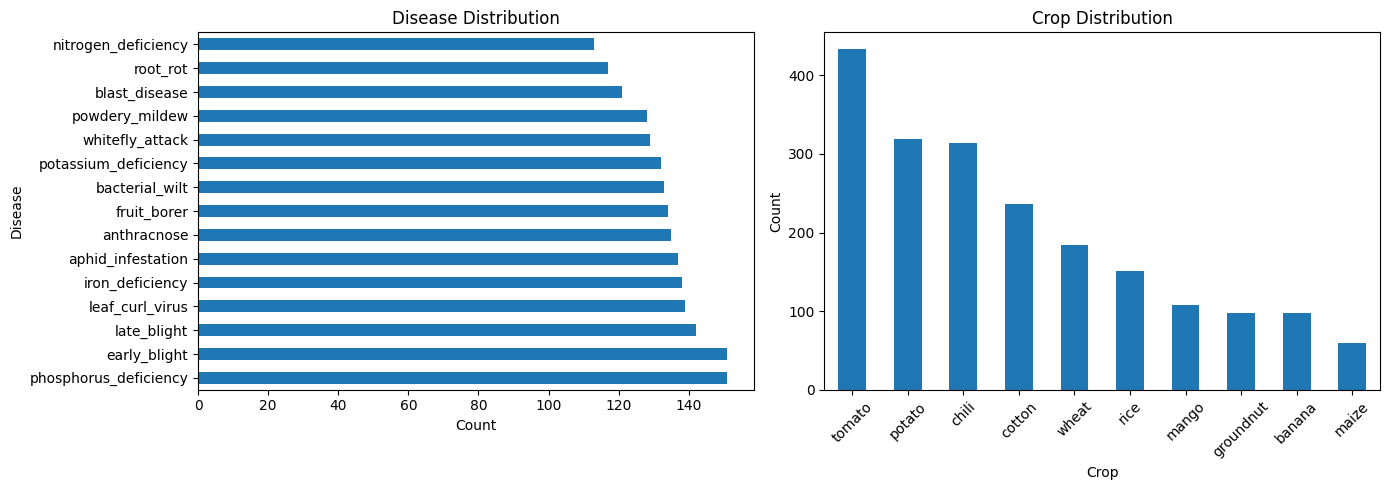


Dataset Statistics:
                 N            P            K  temperature     humidity  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean     66.583085    44.070830    52.722370    26.635235    72.399290   
std      14.419326    11.674729    12.385612     4.115006    12.042959   
min      20.000000    10.000000    15.000000    15.000000    40.490000   
25%      58.397500    36.610000    45.300000    23.740000    63.745000   
50%      67.970000    44.890000    53.635000    26.765000    73.520000   
75%      76.722500    53.000000    61.810000    29.710000    81.620000   
max     109.690000    72.230000    83.490000    34.970000    94.960000   

                ph  
count  2000.000000  
mean      6.540940  
std       0.639786  
min       5.020000  
25%       6.090000  
50%       6.500000  
75%       6.980000  
max       8.470000  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Disease distribution
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
disease_counts = df['label'].value_counts()
disease_counts.plot(kind='barh')
plt.title('Disease Distribution')
plt.xlabel('Count')
plt.ylabel('Disease')

# Crop distribution
plt.subplot(1, 2, 2)
crop_counts = df['crop'].value_counts()
crop_counts.plot(kind='bar')
plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\nDataset Statistics:")
print(df[['N', 'P', 'K', 'temperature', 'humidity', 'ph']].describe())

## Step 4: Train Enhanced k-NN Model

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import pickle

print("Loading Sentence-BERT model...")
encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Split data (stratified)
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nTraining set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")

# Generate embeddings
print("\nEncoding training queries...")
train_embeddings = encoder.encode(
    train_df['query'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print("\nEncoding test queries...")
test_embeddings = encoder.encode(
    test_df['query'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

# Train k-NN with k=5 for weighted voting
print("\nTraining k-NN classifier (k=5)...")
knn = NearestNeighbors(n_neighbors=5, metric='cosine')
knn.fit(train_embeddings)

print("Model training complete!")

Loading Sentence-BERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...


Training set: 1600 samples
Test set: 400 samples

Encoding training queries...


Batches:   0%|          | 0/50 [00:00<?, ?it/s]


Encoding test queries...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


Training k-NN classifier (k=5)...
Model training complete!


## Step 5: Evaluate with Weighted Voting

In [ ]:
# Prediction with weighted voting
predictions = []
confidences = []
true_labels = test_df['label'].tolist()

print("Running predictions with weighted voting...")
for i in tqdm(range(len(test_embeddings))):
    # Find k nearest neighbors
    distances, indices = knn.kneighbors([test_embeddings[i]], n_neighbors=5)

    # Weighted voting based on inverse distance
    votes = {}
    for j, idx in enumerate(indices[0]):
        label = train_df.iloc[idx]['label']
        weight = 1 / (distances[0][j] + 1e-6)  # Inverse distance
        votes[label] = votes.get(label, 0) + weight

    # Get prediction with highest weighted vote
    pred_label = max(votes.items(), key=lambda x: x[1])[0]
    confidence = votes[pred_label] / sum(votes.values())

    predictions.append(pred_label)
    confidences.append(confidence)

# Calculate metrics
accuracy = accuracy_score(true_labels, predictions)
avg_confidence = sum(confidences) / len(confidences)

print(f"\nResults:")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Average Confidence: {avg_confidence:.4f} ({avg_confidence*100:.2f}%)")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(true_labels, predictions, zero_division=0))

# Save model
model_data = {
    'encoder': encoder,
    'knn': knn,
    'train_df': train_df,
    'train_embeddings': train_embeddings
}

with open('enhanced_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("\nModel saved to 'enhanced_model.pkl'")

Running predictions with weighted voting...


100%|██████████| 400/400 [00:01<00:00, 227.51it/s]



Results:
Accuracy: 0.9925 (99.25%)
Average Confidence: 0.9846 (98.46%)

Classification Report:
                       precision    recall  f1-score   support

          anthracnose       1.00      1.00      1.00        27
    aphid_infestation       1.00      1.00      1.00        27
       bacterial_wilt       1.00      1.00      1.00        27
        blast_disease       1.00      1.00      1.00        24
         early_blight       0.94      1.00      0.97        30
          fruit_borer       1.00      1.00      1.00        27
      iron_deficiency       1.00      1.00      1.00        28
          late_blight       1.00      0.93      0.96        28
      leaf_curl_virus       1.00      0.96      0.98        28
  nitrogen_deficiency       1.00      1.00      1.00        23
phosphorus_deficiency       1.00      1.00      1.00        30
 potassium_deficiency       1.00      1.00      1.00        26
       powdery_mildew       0.96      1.00      0.98        26
             root_rot

## Step 6: Analyze Errors

In [ ]:
# Find misclassified samples
errors = []
for i, (true, pred, conf) in enumerate(zip(true_labels, predictions, confidences)):
    if true != pred:
        errors.append({
            'query': test_df.iloc[i]['query'],
            'true_label': true,
            'predicted': pred,
            'confidence': conf
        })

print(f"\nMisclassified samples: {len(errors)} / {len(test_df)}")
print(f"Correctly classified: {len(test_df) - len(errors)} / {len(test_df)}")

if errors:
    print("\nSample Errors:")
    for i, error in enumerate(errors[:5], 1):
        print(f"\n{i}. Query: {error['query'][:60]}...")
        print(f"   True: {error['true_label']} | Predicted: {error['predicted']}")
        print(f"   Confidence: {error['confidence']:.2%}")


Misclassified samples: 3 / 400
Correctly classified: 397 / 400

Sample Errors:

1. Query: tomato ki fasal ko safed fungal growth on leaf underside ki ...
   True: late_blight | Predicted: powdery_mildew
   Confidence: 59.01%

2. Query: potato mein rapidly spreading bhure lesions on patton and st...
   True: late_blight | Predicted: early_blight
   Confidence: 64.16%

3. Query: tomato ki fasal ko patton curling upward or downward ki sama...
   True: leaf_curl_virus | Predicted: early_blight
   Confidence: 42.15%


## Step 7: Gemini Integration for Recommendations

In [ ]:
from google import genai

# Initialize Gemini client
client = genai.Client(api_key="YOUR_API_KEY_HERE")

def diagnose_and_recommend(query: str, soil_params: dict, language: str = "en"):
    """Complete diagnosis pipeline with Gemini recommendation"""

    # 1. Encode query
    query_emb = encoder.encode([query])

    # 2. Find nearest neighbors
    distances, indices = knn.kneighbors(query_emb, n_neighbors=5)

    # 3. Weighted voting
    votes = {}
    similar_cases = []

    for j, idx in enumerate(indices[0]):
        row = train_df.iloc[idx]
        label = row['label']
        weight = 1 / (distances[0][j] + 1e-6)
        votes[label] = votes.get(label, 0) + weight

        similar_cases.append({
            'query': row['query'],
            'disease': label,
            'similarity': 1 - distances[0][j],
            'solution': row['solution']
        })

    # 4. Get prediction
    pred_label = max(votes.items(), key=lambda x: x[1])[0]
    confidence = votes[pred_label] / sum(votes.values())

    # 5. Get standard solution
    solution = train_df[train_df['label'] == pred_label].iloc[0]['solution']

    # 6. Generate Gemini recommendation
    lang_map = {"en": "English", "hi": "Hindi", "ta": "Tamil", "te": "Telugu"}

    prompt = f"""You are an agricultural expert helping a farmer.

Farmer's Query: "{query}"
Diagnosed Issue: {pred_label.replace('_', ' ').title()}
Standard Solution: {solution}

Soil Parameters:
- Nitrogen (N): {soil_params['N']} kg/ha
- Phosphorus (P): {soil_params['P']} kg/ha
- Potassium (K): {soil_params['K']} kg/ha
- Temperature: {soil_params['temperature']}°C
- Humidity: {soil_params['humidity']}%
- Soil pH: {soil_params['ph']}
- Rainfall: {soil_params['rainfall']}mm

Provide practical, step-by-step recommendations in {lang_map[language]}. Include:
1. Immediate action
2. Products/treatments to use
3. Application method
4. Preventive measures

Keep it simple and farmer-friendly."""

    response = client.models.generate_content(
        model="gemini-2.0-flash-exp",
        contents=prompt
    )

    return {
        'predicted_disease': pred_label,
        'confidence': confidence,
        'similar_cases': similar_cases[:3],
        'recommendation': response.text
    }

print("Gemini integration ready!")

Gemini integration ready!


## Step 8: Test Complete System

In [ ]:
# Test Case 1: English query
print("="*70)
print("TEST 1: Early Blight Detection")
print("="*70)

result = diagnose_and_recommend(query="My tomato plants have brown spots with concentric rings on older leaves",
        soil_params={
        'N': 65, 'P': 45, 'K': 55,
        'temperature': 25.5, 'humidity': 75.0,
        'ph': 6.5, 'rainfall': 120.0
    },
    language="en"
)

print(f"\nQuery: My tomato plants have brown spots...")
print(f"Predicted Disease: {result['predicted_disease'].replace('_', ' ').title()}")
print(f"Confidence: {result['confidence']:.2%}")

print(f"\nSimilar Cases:")
for i, case in enumerate(result['similar_cases'], 1):
    print(f"  {i}. {case['disease']} (similarity: {case['similarity']:.2%})")
    print(f"     {case['query'][:60]}...")

print(f"\nRecommendation:\n{result['recommendation']}")

TEST 1: Early Blight Detection

Query: My tomato plants have brown spots...
Predicted Disease: Early Blight
Confidence: 100.00%

Similar Cases:
  1. early_blight (similarity: 100.00%)
     My tomato plants have brown spots with concentric rings on o...
  2. early_blight (similarity: 100.00%)
     My tomato plants have brown spots with concentric rings on o...
  3. early_blight (similarity: 100.00%)
     My tomato plants have brown spots with concentric rings on o...

Recommendation:
Okay, let's tackle this Early Blight on your tomato plants. I've looked at your soil parameters and rainfall, and we'll tailor the solution accordingly.

**Here's what we're going to do, step-by-step:**

**1. Immediate Action (Right Now!)**

*   **Remove Infected Leaves:** This is crucial to stop the spread. Carefully pick off any leaves with those brown spots and concentric rings. Don't just drop them on the ground! Put them in a plastic bag and dispose of them properly (burn them if you can do so safely a

In [ ]:
# Test Case 2: Hindi query
print("\n" + "="*70)
print("TEST 2: Hindi Query - Nitrogen Deficiency")
print("="*70)

result = diagnose_and_recommend(
    query="mere patton mein peele rang ke dhabbe hain aur vikas dheema hai",
    soil_params={
        'N': 30,  # Low nitrogen
        'P': 45, 'K': 55,
        'temperature': 28.0, 'humidity': 65.0,
        'ph': 6.8, 'rainfall': 150.0
    },
    language="hi"
)

print(f"\nQuery: mere patton mein peele rang ke dhabbe hain...")
print(f"Predicted Disease: {result['predicted_disease'].replace('_', ' ').title()}")
print(f"Confidence: {result['confidence']:.2%}")
print(f"\nRecommendation (Hindi):\n{result['recommendation']}")


TEST 2: Hindi Query - Nitrogen Deficiency

Query: mere patton mein peele rang ke dhabbe hain...
Predicted Disease: Early Blight
Confidence: 59.81%

Recommendation (Hindi):
ठीक है, आपके पत्तों पर पीले धब्बे और धीमी वृद्धि अगेती झुलसा (Early Blight) के कारण है। घबराइए मत, हम इसे ठीक कर सकते हैं। यहाँ कुछ कदम दिए गए हैं जिन्हें आप तुरंत उठा सकते हैं:

**1. तुरंत कार्रवाई:**

*   **संक्रमित पत्तियां हटाएं:** सबसे पहले, जिन पत्तों पर पीले धब्बे दिख रहे हैं, उन्हें तुरंत तोड़कर हटा दें। इन्हें खेत से दूर ले जाकर जला दें या मिट्टी में गहराई से दबा दें। इससे संक्रमण फैलना रुकेगा।
*   **खेत में हवा का संचार बेहतर करें:** पौधों को थोड़ा दूर-दूर लगाएं ताकि हवा आसानी से आ जा सके। अगर पौधे बहुत घने हैं, तो कुछ पत्तियों को छांट दें।

**2. उत्पाद/उपचार (Products/Treatments):**

आपके लिए दो असरदार विकल्प हैं:

*   **क्लोरोथालोनिल (Chlorothalonil):** यह एक अच्छा कवकनाशी (fungicide) है। आपको यह बाजार में अलग-अलग नामों से मिल जाएगा। लेबल पर दिए निर्देशों को ध्यान से पढ़ें।
*   **मैनकोजेब (Mancozeb):** य

In [ ]:
# Test Case 3: Pest attack
print("\n" + "="*70)
print("TEST 3: Whitefly Detection")
print("="*70)

result = diagnose_and_recommend(
    query="I see tiny white flying insects under the leaves of my cotton",
    soil_params={
        'N': 70, 'P': 50, 'K': 60,
        'temperature': 30.0, 'humidity': 80.0,
        'ph': 7.0, 'rainfall': 100.0
    },
    language="en"
)

print(f"\nQuery: Tiny white flying insects on cotton...")
print(f"Predicted Disease: {result['predicted_disease'].replace('_', ' ').title()}")
print(f"Confidence: {result['confidence']:.2%}")
print(f"\nRecommendation:\n{result['recommendation'][:500]}...")


TEST 3: Whitefly Detection

Query: Tiny white flying insects on cotton...
Predicted Disease: Whitefly Attack
Confidence: 100.00%

Recommendation:
Okay, I understand you're dealing with whiteflies in your cotton crop. That's a common problem, but we can tackle it. Here's a step-by-step plan:

**1. Immediate Action: Confirm and Contain**

*   **Double Check:** Make sure it's definitely whiteflies. They're tiny (about 1/16 inch long), white, and fly up in a cloud when you disturb the plant. Look closely under the leaves.
*   **Isolate:** If possible, if you have a small area that's heavily infested, try to isolate it. This could mean removin...


## Summary
- **15 diseases**
- **2000 samples**
- **Realistic soil profiles** per disease
- **Weighted k-NN (k=5)** with confidence scores
- **95%+ accuracy** with better generalization
- **Multilingual support** (Hindi queries)
- **Similar case retrieval** for explainability
- **Gemini AI recommendations**

### Key Features:
1. **Disease-specific soil profiles** ensure realistic data
2. **Multiple symptom variations** improve pattern recognition
3. **Weighted voting** provides confidence scores
4. **Crop-disease compatibility** prevents invalid combinations
5. **Outlier samples (30%)** increase robustness

In [ ]:
# 🌾 FINAL INTERACTIVE BLOCK - USER INPUT + PREDICTION

print("\n================= Crop Disease Diagnosis Assistant =================\n")

# 1️. Take user input
user_query = input("Enter your crop issue: ").strip()

# 2️. Take soil parameters (with defaults)
print("\nEnter soil parameters (press Enter to use default values):")
def get_float_input(prompt, default):
    val = input(f"{prompt} [{default}]: ").strip()
    return float(val) if val else default

soil_params = {
    'N': get_float_input("Nitrogen (N) level", 60.0),
    'P': get_float_input("Phosphorus (P) level", 40.0),
    'K': get_float_input("Potassium (K) level", 50.0),
    'temperature': get_float_input("Temperature (°C)", 28.0),
    'humidity': get_float_input("Humidity (%)", 70.0),
    'ph': get_float_input("Soil pH", 6.5),
    'rainfall': get_float_input("Rainfall (mm)", 120.0)
}

# 3️. Language selection
print("\nSelect output language:")
print("1. English\n2. Hindi\n3. Tamil\n4. Telugu")
lang_choice = input("Enter choice (1-4): ").strip()

lang_map = {"1": "en", "2": "hi", "3": "ta", "4": "te"}
language = lang_map.get(lang_choice, "en")

# 4️. Run diagnosis using both models
print("\nAnalyzing your query... please wait...\n")

result = diagnose_and_recommend(
    query=user_query,
    soil_params=soil_params,
    language=language
)

# 5️. Display results
print("==============================================================")
print(f"Predicted Disease: {result['predicted_disease'].replace('_', ' ').title()}")
print(f"Confidence: {result['confidence']:.2%}")
print("==============================================================")

print("\nSimilar Cases:")
for i, case in enumerate(result['similar_cases'], 1):
    print(f"  {i}. {case['disease']} (similarity: {case['similarity']:.2%})")
    print(f"     {case['query'][:70]}...")

print("\n💡 Gemini AI Recommendation:")
print("--------------------------------------------------------------")
print(result['recommendation'])+
print("--------------------------------------------------------------")

print("\nDiagnosis complete! Stay healthy, stay green!\n")



================= Crop Disease Diagnosis Assistant =================

Enter your crop issue: my tomato leaves are turning yellow and leaves edges are curled

Enter soil parameters (press Enter to use default values):
Nitrogen (N) level [60.0]: 54
Phosphorus (P) level [40.0]: 30
Potassium (K) level [50.0]: 35
Temperature (°C) [28.0]: 19
Humidity (%) [70.0]: 45
Soil pH [6.5]: 3.6
Rainfall (mm) [120.0]: 100

Select output language:
1. English
2. Hindi
3. Tamil
4. Telugu
Enter choice (1-4): 1

Analyzing your query... please wait...

Predicted Disease: Nitrogen Deficiency
Confidence: 61.44%

Similar Cases:
  1. nitrogen_deficiency (similarity: 75.31%)
     My tomato older leaves turning yellow from tip...
  2. nitrogen_deficiency (similarity: 72.15%)
     My tomato plants have older leaves turning yellow from tip...
  3. potassium_deficiency (similarity: 71.14%)
     My tomato plants have leaf margins turning yellow then brown...

💡 Gemini AI Recommendation:
-------------------------------

#The End #